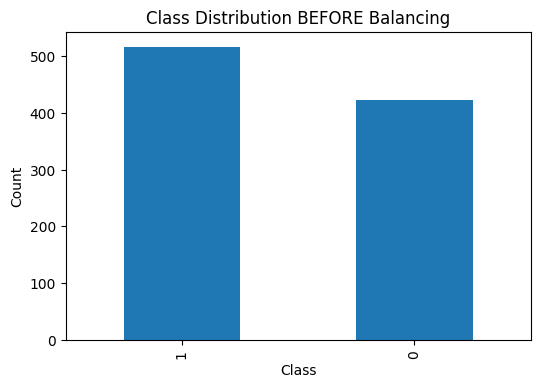

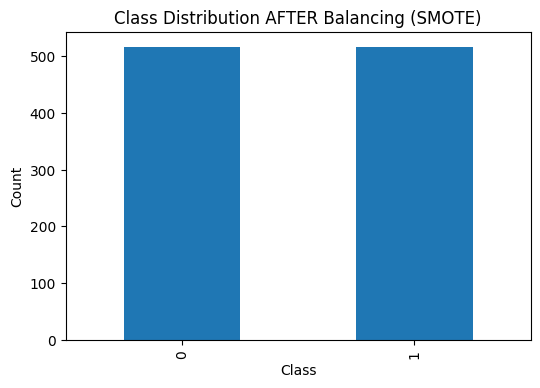

Original Training Set Class Distribution:
Target
1    517
0    422
Name: count, dtype: int64

Balanced Training Set Class Distribution:
Target
0    517
1    517
Name: count, dtype: int64
Balanced dataset saved as 'IT24101341_balanced.xlsx'


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE  # install via: pip install imbalanced-learn

# 1. Load Dataset
df = pd.read_excel("/content/drive/MyDrive/IT24201236.xlsx", index_col="Date")

# 2. Create Daily Returns Column
df['ret_1d'] = df['Adj Close**'].pct_change().fillna(0)

# 3. Reset Index (so Date is a column again)
df = df.reset_index()

# -------------------- DATA BALANCING --------------------
# Define Target: Positive return (1) or Negative return (0)
df['Target'] = (df['ret_1d'] > 0).astype(int)

# Define Features (X) and Target (y)
X = df.drop(columns=['Target', 'Date'])  # remove target + date
y = df['Target']

# Split into Train & Test (balance only the training set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Plot class distribution before balancing
plt.figure(figsize=(6,4))
y_train.value_counts().plot(kind='bar')
plt.title("Class Distribution BEFORE Balancing")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Apply SMOTE Oversampling
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Plot class distribution after balancing
plt.figure(figsize=(6,4))
y_train_bal.value_counts().plot(kind='bar')
plt.title("Class Distribution AFTER Balancing (SMOTE)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print("Original Training Set Class Distribution:")
print(y_train.value_counts())
print("\nBalanced Training Set Class Distribution:")
print(y_train_bal.value_counts())

# Create final balanced dataframe for saving
balanced_df = pd.DataFrame(X_train_bal, columns=X_train.columns)
balanced_df['Target'] = y_train_bal

# 4. Save Final Preprocessed Dataset
balanced_df.to_excel("IT24101341_balanced.xlsx", index=False)
print("Balanced dataset saved as 'IT24101341_balanced.xlsx'")
